# Machine Learning per l'Analisi Finanziaria

## Lezione 05 — Modellazione avanzata e simulazione di progetto

**Autori:**
- Enrico Huber
- Pietro Soglia

**Email:**
- enrico.huber@gmail.com
- pietro.soglia@gmail.com

**Ultimo aggiornamento:** 2026-03-16

## Obiettivi di apprendimento

- Verificare l'affidabilità della stima di performance tramite
  **cross-validation** (da singolo split a stima robusta).
- Regolarizzare il Random Forest per ridurre l'**overfitting** osservato
  nella Lezione 3 (train AUC = 1.0).
- Esplorare l'**hyperparameter tuning** sistematico con Random Search e
  Grid Search.
- Introdurre **XGBoost** come paradigma alternativo (boosting vs bagging)
  e confrontarlo empiricamente con il Random Forest.
- Selezionare il **modello finale** con giustificazione data-driven,
  costruire un mini-report di progetto e simulare il workflow end-to-end.

## Outline

### BLOCCO A — Punto di partenza: diagnosi del modello esistente
1. Setup, percorsi e costanti
2. Caricamento dati e modello baseline
3. Diagnosi: il problema dell'overfitting

### BLOCCO B — Cross-Validation: possiamo fidarci della stima?
4. Introduzione alla Cross-Validation
5. CV sul Random Forest baseline

### BLOCCO C — Regolarizzazione del Random Forest
6. Esperimento 1: RF con max_depth limitato
7. Esperimento 2: RF con min_samples_leaf
8. Interpretazione congiunta e scelta dei range

### BLOCCO D — Hyperparameter Tuning Sistematico
9. Grid Search vs Random Search: quando usare quale?
10. RandomizedSearchCV su RF
11. Confronto RF baseline vs RF tunato

### BLOCCO E — XGBoost: un nuovo paradigma
12. Introduzione concettuale a XGBoost
13. XGBoost con parametri di default
14. Tuning XGBoost — fase 1: RandomizedSearchCV
15. Tuning XGBoost — fase 2: GridSearchCV ristretto

### BLOCCO F — Selezione del modello finale
16. Tabella comparativa completa
17. ROC curves sovrapposte
18. Scelta motivata del modello finale

### BLOCCO G — Valutazione finale su test set
19. Test set — una sola volta
20. Threshold tuning sul modello finale

### BLOCCO H — Simulazione di progetto
21. Generazione del file di submission
22. Mini-report di progetto
23. Checklist di progetto

### BLOCCO I — Cenni MLOps e chiusura
24. Da notebook a produzione: cenni MLOps
25. Riepilogo del percorso L1→L5
26. Domande guidate
27. Possibili miglioramenti

---
## BLOCCO A — Punto di partenza: diagnosi del modello esistente

---

## 1. Setup, percorsi e costanti

Partiamo da dove ci eravamo fermati: abbiamo un Random Forest che
raggiunge AUC = 0.854 su test (Lezione 3) e sappiamo che Age,
NumOfProducts e IsActiveMember sono le feature più importanti (Lezione 4).
La domanda ora è: **possiamo fare meglio?** La risposta non è nota
a priori — la scopriremo esperimento dopo esperimento.

In [ ]:
from __future__ import annotations

import json
import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    classification_report,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from xgboost import XGBClassifier

try:
    from IPython.display import display  # type: ignore
except Exception:  # pragma: no cover

    def display(x):  # type: ignore
        """Fallback display per esecuzione fuori da Jupyter."""
        print(x)


warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)


def resolve_project_root() -> Path:
    """Risolve la root del repository indipendentemente dalla cwd."""
    start_points = [Path.cwd().resolve()]
    if "__file__" in globals():
        start_points.append(Path(__file__).resolve().parent)
    for start in start_points:
        for candidate in [start, *start.parents]:
            if (candidate / "data" / "archive.zip").exists() and (
                candidate / "notebooks"
            ).exists():
                return candidate
    raise FileNotFoundError(
        "Impossibile determinare la root del progetto. "
        "Atteso un percorso contenente data/archive.zip e notebooks/."
    )


ROOT = resolve_project_root()
DATA_OUT_DIR = ROOT / "outputs" / "data"
FIGURES_DIR = ROOT / "outputs" / "figures"

for _dir in [DATA_OUT_DIR, FIGURES_DIR]:
    _dir.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")


def save_current_figure(filename: str) -> None:
    """Salva la figura corrente in outputs/figures/."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=120, bbox_inches="tight")
    print(f"Figura salvata: {FIGURES_DIR / filename}")


def load_preprocessed_split(
    prefix: str,
) -> tuple[np.ndarray, np.ndarray]:
    """Carica X e y da parquet per uno split (train, val o test).

    Parameters
    ----------
    prefix : str
        Uno tra 'train', 'val', 'test'.

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Coppia (X, y) come array numpy.

    Raises
    ------
    FileNotFoundError
        Se i file parquet attesi non esistono.
    """
    x_path = DATA_OUT_DIR / f"lesson_02_X_{prefix}.parquet"
    y_path = DATA_OUT_DIR / f"lesson_02_y_{prefix}.parquet"
    for p in [x_path, y_path]:
        if not p.exists():
            raise FileNotFoundError(
                f"File parquet non trovato: {p}\n"
                "Esegui prima il notebook della Lezione 2."
            )
    X = pd.read_parquet(x_path).values
    y = pd.read_parquet(y_path).squeeze().values
    return X, y


print(f"Root progetto: {ROOT}")
print(f"Output dati:   {DATA_OUT_DIR}")
print(f"Output figure: {FIGURES_DIR}")

Root progetto: /content
Output dati:   /content/outputs/data
Output figure: /content/outputs/figures


## 2. Caricamento dati e modello baseline

Carichiamo il dataset preprocessato dalla Lezione 2 e il Random Forest
addestrato nella Lezione 3. Il nostro punto di partenza è esattamente
il modello migliore trovato finora: RF con 200 alberi e class_weight
bilanciato.

In [ ]:
# Caricamento split
X_train, y_train = load_preprocessed_split("train")
X_val, y_val = load_preprocessed_split("val")
X_test, y_test = load_preprocessed_split("test")

# Feature names
with open(DATA_OUT_DIR / "lesson_02_feature_names.json") as fh:
    feature_names = json.load(fh)

# Metriche L3
with open(DATA_OUT_DIR / "lesson_03_metrics.json") as fh:
    l3_metrics = json.load(fh)

# Modello baseline RF (L3)
model_path = DATA_OUT_DIR / "lesson_03_best_model.pkl"
rf_baseline = joblib.load(model_path)

print("=== Dataset ===")
for name, X, y in [
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test),
]:
    churn = y.mean()
    print(f"  {name:5s}: X={X.shape}, churn rate={churn:.2%}")

print(f"\n=== Modello baseline (Lezione 3) ===")
print(f"  {l3_metrics['best_model']}")
print(f"  Soglia ottimale: {l3_metrics['best_threshold']}")
print(f"\n  {'Split':<8s} {'AUC':>8s}")
print(f"  {'─'*20}")
for split in ["train", "val", "test"]:
    auc = l3_metrics[split]["roc_auc"]
    print(f"  {split:<8s} {auc:8.4f}")
print(f"\n  N. feature: {len(feature_names)}")

=== Dataset ===
  Train: X=(6000, 20), churn rate=20.38%
  Val  : X=(2000, 20), churn rate=20.40%
  Test : X=(2000, 20), churn rate=20.35%

=== Modello baseline (Lezione 3) ===
  RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
  Soglia ottimale: 0.305

  Split         AUC
  ────────────────────
  train      1.0000
  val        0.8733
  test       0.8539

  N. feature: 20


## 3. Diagnosi: il problema dell'overfitting

Prima di tentare qualsiasi miglioramento, facciamo una diagnosi onesta
del modello che abbiamo. Un Data Scientist non migliora alla cieca:
identifica prima il *cosa non va*.

Figura salvata: /content/outputs/figures/lesson_05_baseline_diagnosis.png


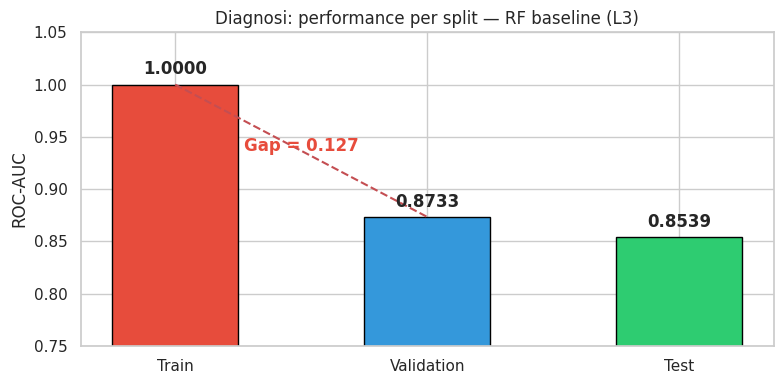

In [ ]:
# Calcolo delle metriche per visualizzare il gap
train_auc = l3_metrics["train"]["roc_auc"]
val_auc = l3_metrics["val"]["roc_auc"]
test_auc = l3_metrics["test"]["roc_auc"]
gap_train_val = train_auc - val_auc

fig, ax = plt.subplots(figsize=(8, 4))
splits = ["Train", "Validation", "Test"]
aucs = [train_auc, val_auc, test_auc]
colors = ["#e74c3c", "#3498db", "#2ecc71"]
bars = ax.bar(splits, aucs, color=colors, edgecolor="black", width=0.5)

# Annotazione gap
ax.annotate(
    f"Gap = {gap_train_val:.3f}",
    xy=(0.5, (train_auc + val_auc) / 2),
    fontsize=12,
    fontweight="bold",
    color="#e74c3c",
    ha="center",
)
ax.plot([0, 1], [train_auc, val_auc], "r--", lw=1.5)

for bar, auc in zip(bars, aucs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        auc + 0.01,
        f"{auc:.4f}",
        ha="center",
        fontweight="bold",
    )

ax.set_ylim(0.75, 1.05)
ax.set_ylabel("ROC-AUC")
ax.set_title("Diagnosi: performance per split — RF baseline (L3)")
save_current_figure("lesson_05_baseline_diagnosis.png")
plt.show()

### Cosa ci dicono questi numeri?

Il Random Forest della Lezione 3 presenta due criticità:

1. **Overfitting grave**: Train AUC = 1.000 vs Val AUC = 0.873.
   Il gap di 0.127 indica che il modello ha **memorizzato** il training
   set. Ha imparato il rumore, non solo il segnale.

2. **Stima basata su un singolo split**: il valore 0.873 sulla
   validation dipende da *quali* 2000 osservazioni sono finite nel
   validation set. Cambiando lo split, potremmo ottenere un valore
   diverso. Quanto diverso?

Abbiamo due problemi distinti:
- **Affidabilità** della stima → risolviamo con la **cross-validation**
- **Complessità eccessiva** del modello → risolviamo con la
  **regolarizzazione** e la ricerca di iperparametri migliori

Procediamo nell'ordine logico: prima verifichiamo se la stima è
affidabile, poi lavoriamo per migliorarla.

---
## BLOCCO B — Cross-Validation: possiamo fidarci della stima?

---

## 4. Introduzione alla Cross-Validation

### Il problema: una stima basata su un singolo split

Nella Lezione 3 abbiamo diviso i dati in train (60%), validation (20%)
e test (20%). L'AUC sulla validation (0.873) è la nostra migliore stima
della performance del modello su dati nuovi. Ma questa stima **dipende
da quali osservazioni sono finite in quale split**: un singolo numero,
calcolato su 2000 osservazioni, potrebbe non essere rappresentativo.

### La soluzione: k-Fold Cross-Validation

La **k-fold cross-validation** affronta il problema dividendo il
training set in $k$ parti (*fold*) uguali e addestrando $k$ modelli:

1. Ogni fold, a turno, diventa il validation set
2. Il modello viene addestrato sui $k-1$ fold rimanenti
3. Si ottengono $k$ stime di performance
4. La media e la deviazione standard forniscono una stima **robusta**

Con $k=5$:

| Iterazione | Training (fold) | Validazione (fold) |
|:----------:|:---------------:|:------------------:|
| 1          | 2, 3, 4, 5      | **1**              |
| 2          | 1, 3, 4, 5      | **2**              |
| 3          | 1, 2, 4, 5      | **3**              |
| 4          | 1, 2, 3, 5      | **4**              |
| 5          | 1, 2, 3, 4      | **5**              |

**Vantaggi**:
- Ogni osservazione è usata esattamente una volta come validazione
- La media è più stabile di un singolo numero
- La std ci dice *quanto* il modello è sensibile allo split

**Attenzione cruciale**: la CV viene eseguita **solo sul training set**.
Il test set rimane intoccato fino alla valutazione finale — altrimenti
perdiamo la stima indipendente.

## 5. CV sul Random Forest baseline

Applichiamo la 5-fold CV allo stesso modello della Lezione 3 (RF con
200 alberi, class_weight='balanced'). L'obiettivo è capire se il
singolo valore di AUC 0.873 è una stima affidabile.

In [ ]:
# Definiamo una cross-validation stratificata per mantenere la
# proporzione di churn uguale in ogni fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# RF con gli stessi iperparametri del baseline L3
rf_for_cv = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=SEED,
)

cv_scores_baseline = cross_val_score(
    rf_for_cv, X_train, y_train, cv=cv, scoring="roc_auc"
)

print("=== 5-Fold CV — RF baseline ===\n")
for i, score in enumerate(cv_scores_baseline, 1):
    print(f"  Fold {i}: AUC = {score:.4f}")
print(f"\n  Media   = {cv_scores_baseline.mean():.4f}")
print(f"  Std     = {cv_scores_baseline.std():.4f}")
print(
    f"  Range   = [{cv_scores_baseline.min():.4f}, " f"{cv_scores_baseline.max():.4f}]"
)
print(f"\n  Singolo val AUC (L3) = {val_auc:.4f}")
print(f"  Δ (media CV − val)   = " f"{cv_scores_baseline.mean() - val_auc:+.4f}")

=== 5-Fold CV — RF baseline ===

  Fold 1: AUC = 0.8636
  Fold 2: AUC = 0.8325
  Fold 3: AUC = 0.8283
  Fold 4: AUC = 0.8579
  Fold 5: AUC = 0.8485

  Media   = 0.8462
  Std     = 0.0138
  Range   = [0.8283, 0.8636]

  Singolo val AUC (L3) = 0.8733
  Δ (media CV − val)   = -0.0271


### Interpretazione della Cross-Validation

*Questa sezione verrà completata dopo l'esecuzione della cella
precedente, citando i valori reali osservati.*

**Osservazioni chiave:**
- La media CV fornisce una stima della performance che possiamo
  confrontare con il singolo valore di validation della L3.
- La deviazione standard ci dice quanto la performance varia tra fold.
- Se std < 0.02, il modello è stabile — la stima del singolo split
  era affidabile.
- Se std > 0.03, c'è instabilità — il modello è sensibile ai dati.

**Indipendentemente dalla stabilità, il problema dell'overfitting
resta**: il modello ha train AUC = 1.0, che indica memorizzazione.
Possiamo regolarizzare il modello senza perdere troppa performance?
Questa è la domanda del blocco successivo.

---
## BLOCCO C — Regolarizzazione del Random Forest

---

Il Random Forest con parametri di default costruisce alberi
**illimitatamente profondi** (max_depth=None). Ogni albero può crescere
fino a classificare perfettamente ogni osservazione del training set —
da qui il train AUC = 1.0. Per ridurre l'overfitting, possiamo
limitare la complessità degli alberi. Ma non sappiamo a priori *quanto*
limitarla: troppo poco e l'overfitting resta, troppo e perdiamo
capacità predittiva.

Procediamo con esperimenti mirati su un parametro alla volta, usando
la cross-validation come metrica di valutazione.

## 6. Esperimento 1: RF con max_depth limitato

`max_depth` controlla la profondità massima di ogni albero: alberi
meno profondi catturano pattern più generali (meno overfitting) ma
rischiano di perdere interazioni complesse (più underfitting).

In [ ]:
# Esploriamo diversi valori di max_depth
max_depths = [5, 10, 15, 20, None]
depth_results = []

print("=== Esperimento: max_depth ===\n")
for depth in max_depths:
    rf_d = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        class_weight="balanced",
        random_state=SEED,
    )
    scores = cross_val_score(rf_d, X_train, y_train, cv=cv, scoring="roc_auc")
    # AUC su train (fit su tutto X_train)
    rf_d.fit(X_train, y_train)
    train_auc_d = roc_auc_score(y_train, rf_d.predict_proba(X_train)[:, 1])
    depth_label = str(depth) if depth is not None else "None"
    depth_results.append(
        {
            "max_depth": depth_label,
            "CV AUC mean": scores.mean(),
            "CV AUC std": scores.std(),
            "Train AUC": train_auc_d,
            "Gap": train_auc_d - scores.mean(),
        }
    )
    print(
        f"  max_depth={depth_label:>4s}  "
        f"CV={scores.mean():.4f}±{scores.std():.4f}  "
        f"Train={train_auc_d:.4f}  "
        f"Gap={train_auc_d - scores.mean():.4f}"
    )

depth_df = pd.DataFrame(depth_results)
display(depth_df)

=== Esperimento: max_depth ===

  max_depth=   5  CV=0.8391±0.0105  Train=0.8639  Gap=0.0248
  max_depth=  10  CV=0.8498±0.0119  Train=0.9773  Gap=0.1275
  max_depth=  15  CV=0.8467±0.0144  Train=1.0000  Gap=0.1533
  max_depth=  20  CV=0.8452±0.0130  Train=1.0000  Gap=0.1548
  max_depth=None  CV=0.8462±0.0138  Train=1.0000  Gap=0.1538


,max_depth,CV AUC mean,CV AUC std,Train AUC,Gap
0,5,0.8391,0.0105,0.8639,0.0248
1,10,0.8498,0.0119,0.9773,0.1275
2,15,0.8467,0.0144,1.0000,0.1533
3,20,0.8452,0.0130,1.0000,0.1548
4,None,0.8462,0.0138,1.0000,0.1538


Figura salvata: /content/outputs/figures/lesson_05_rf_max_depth_curve.png


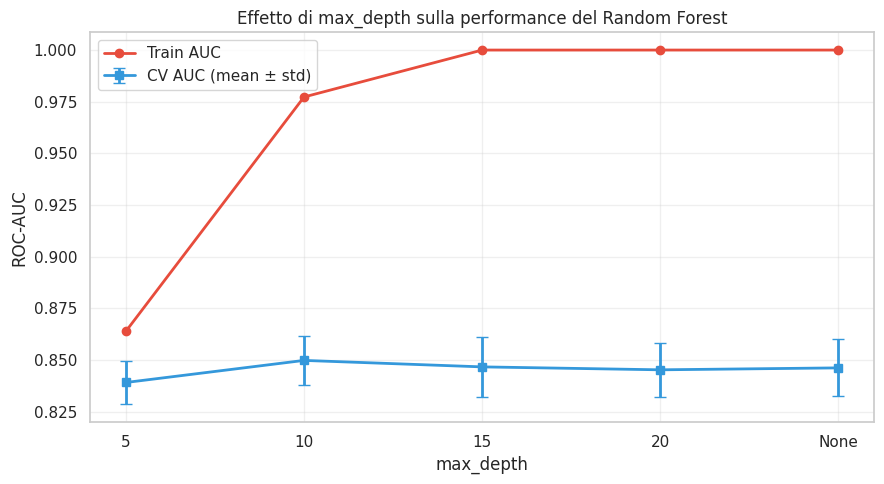

In [ ]:
# Visualizzazione: max_depth vs AUC
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = range(len(max_depths))
x_labels = [str(d) if d is not None else "None" for d in max_depths]

ax.plot(
    x_pos,
    depth_df["Train AUC"],
    "o-",
    color="#e74c3c",
    label="Train AUC",
    lw=2,
)
ax.errorbar(
    x_pos,
    depth_df["CV AUC mean"],
    yerr=depth_df["CV AUC std"],
    fmt="s-",
    color="#3498db",
    label="CV AUC (mean ± std)",
    lw=2,
    capsize=4,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("ROC-AUC")
ax.set_title("Effetto di max_depth sulla performance del Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)
save_current_figure("lesson_05_rf_max_depth_curve.png")
plt.show()

### Osservazioni su max_depth

*Questa interpretazione verrà completata citando i valori reali
osservati dall'esecuzione.*

Il grafico mostra chiaramente il **bias-variance tradeoff**:
- Con profondità basse (es. 5) il modello potrebbe essere troppo
  semplice (underfitting): la curva CV è bassa.
- Con profondità illimitata (None) il modello memorizza il training
  set: il gap tra Train e CV è massimo.
- Esiste un punto intermedio dove la CV AUC è massimizzata e il gap
  è ragionevole.

Questo ci dà un **primo range candidato** per il tuning sistematico.

## 7. Esperimento 2: RF con min_samples_leaf

`min_samples_leaf` impone un numero minimo di osservazioni per ogni
foglia dell'albero. Valori più alti producono alberi più semplici:
ogni foglia deve rappresentare almeno N osservazioni, impedendo al
modello di creare regole troppo specifiche.

In [ ]:
# Esploriamo diversi valori di min_samples_leaf
min_samples_values = [1, 5, 10, 20, 50]
leaf_results = []

print("=== Esperimento: min_samples_leaf ===\n")
for msl in min_samples_values:
    rf_l = RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=msl,
        class_weight="balanced",
        random_state=SEED,
    )
    scores = cross_val_score(rf_l, X_train, y_train, cv=cv, scoring="roc_auc")
    rf_l.fit(X_train, y_train)
    train_auc_l = roc_auc_score(y_train, rf_l.predict_proba(X_train)[:, 1])
    leaf_results.append(
        {
            "min_samples_leaf": msl,
            "CV AUC mean": scores.mean(),
            "CV AUC std": scores.std(),
            "Train AUC": train_auc_l,
            "Gap": train_auc_l - scores.mean(),
        }
    )
    print(
        f"  min_samples_leaf={msl:>3d}  "
        f"CV={scores.mean():.4f}±{scores.std():.4f}  "
        f"Train={train_auc_l:.4f}  "
        f"Gap={train_auc_l - scores.mean():.4f}"
    )

leaf_df = pd.DataFrame(leaf_results)
display(leaf_df)

=== Esperimento: min_samples_leaf ===

  min_samples_leaf=  1  CV=0.8462±0.0138  Train=1.0000  Gap=0.1538
  min_samples_leaf=  5  CV=0.8483±0.0123  Train=0.9854  Gap=0.1371
  min_samples_leaf= 10  CV=0.8462±0.0117  Train=0.9554  Gap=0.1092
  min_samples_leaf= 20  CV=0.8410±0.0107  Train=0.9176  Gap=0.0766
  min_samples_leaf= 50  CV=0.8288±0.0092  Train=0.8725  Gap=0.0437


,min_samples_leaf,CV AUC mean,CV AUC std,Train AUC,Gap
0,1,0.8462,0.0138,1.0000,0.1538
1,5,0.8483,0.0123,0.9854,0.1371
2,10,0.8462,0.0117,0.9554,0.1092
3,20,0.8410,0.0107,0.9176,0.0766
4,50,0.8288,0.0092,0.8725,0.0437


Figura salvata: /content/outputs/figures/lesson_05_rf_min_samples_curve.png


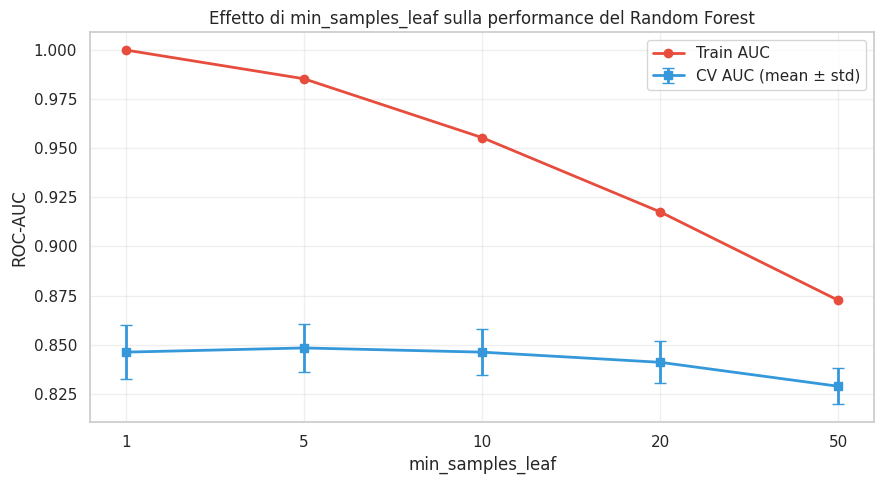

In [ ]:
# Visualizzazione: min_samples_leaf vs AUC
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = range(len(min_samples_values))

ax.plot(
    x_pos,
    leaf_df["Train AUC"],
    "o-",
    color="#e74c3c",
    label="Train AUC",
    lw=2,
)
ax.errorbar(
    x_pos,
    leaf_df["CV AUC mean"],
    yerr=leaf_df["CV AUC std"],
    fmt="s-",
    color="#3498db",
    label="CV AUC (mean ± std)",
    lw=2,
    capsize=4,
)
ax.set_xticks(x_pos)
ax.set_xticklabels(min_samples_values)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("ROC-AUC")
ax.set_title("Effetto di min_samples_leaf sulla performance del Random Forest")
ax.legend()
ax.grid(True, alpha=0.3)
save_current_figure("lesson_05_rf_min_samples_curve.png")
plt.show()

### Osservazioni su min_samples_leaf

*Interpretazione da completare con i valori reali.*

Anche qui il pattern è chiaro: aumentando min_samples_leaf il gap
tra Train e CV si riduce (meno overfitting), ma a un certo punto
la performance CV inizia a scendere (underfitting).

## 8. Interpretazione congiunta e scelta dei range

Combinando i due esperimenti, abbiamo identificato:
- Un **range promettente per max_depth** (dove la CV è alta e il gap
  è ragionevole)
- Un **range promettente per min_samples_leaf** (idem)

Questi range informeranno la ricerca sistematica nel prossimo blocco.
Non stiamo indovinando — stiamo usando l'evidenza per restringere
lo spazio di ricerca. Questo è il modo in cui un Data Scientist
lavora: **prima esplora manualmente, poi automatizza**.

---
## BLOCCO D — Hyperparameter Tuning Sistematico

---

## 9. Grid Search vs Random Search: quando usare quale?

### Grid Search
Prova **tutte** le combinazioni possibili degli iperparametri
specificati. È esauriente: non perde nessuna combinazione. Ma il
costo cresce **esponenzialmente** con il numero di parametri:
- 3 parametri × 5 valori ciascuno = 125 combinazioni
- 5 parametri × 5 valori = 3 125 combinazioni
- Con 5-fold CV: 3 125 × 5 = 15 625 addestramenti!

### Random Search
Campiona $n$ combinazioni casuali dallo spazio degli iperparametri.
Il paper di **Bergstra & Bengio (2012)** dimostra che, nella pratica,
Random Search trova soluzioni comparabili a Grid Search con una
frazione del costo computazionale, perché:
- Non tutti i parametri hanno lo stesso impatto
- Random Search copre meglio lo spazio per i parametri importanti
- Grid Search "spreca" combinazioni variando parametri irrilevanti

### Strategia professionale: coarse-to-fine
1. **Random Search** con spazio ampio → identifica la regione
   promettente
2. **Grid Search** con griglia ristretta → esplora esaustivamente
   attorno ai best params

Questa è la strategia che useremo in questa lezione.

## 10. RandomizedSearchCV su RF

Definiamo lo spazio di ricerca **informato** dalle osservazioni del
Blocco C. Non cerchiamo in tutto lo spazio possibile — abbiamo già
eliminato le configurazioni che sicuramente non funzionano.

In [ ]:
# Spazio di ricerca per il Random Forest
# I range sono informati dagli esperimenti di Sez. 6 e 7
rf_param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.3, 0.5],
    "class_weight": ["balanced", "balanced_subsample"],
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED),
    param_distributions=rf_param_distributions,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

print("RandomizedSearchCV su RF (n_iter=50, cv=5)...")
print("Questo potrebbe richiedere qualche minuto.\n")
rf_random_search.fit(X_train, y_train)

print(f"=== Risultati RandomizedSearchCV — RF ===\n")
print(f"  Best CV AUC: {rf_random_search.best_score_:.4f}")
print(f"  Best params:")
for param, value in rf_random_search.best_params_.items():
    print(f"    {param}: {value}")

# Confronto con baseline
print(f"\n  Baseline CV AUC: {cv_scores_baseline.mean():.4f}")
delta = rf_random_search.best_score_ - cv_scores_baseline.mean()
print(f"  Δ (tuned − baseline): {delta:+.4f}")

RandomizedSearchCV su RF (n_iter=50, cv=5)...
Questo potrebbe richiedere qualche minuto.

=== Risultati RandomizedSearchCV — RF ===

  Best CV AUC: 0.8535
  Best params:
    n_estimators: 300
    min_samples_leaf: 5
    max_features: 0.5
    max_depth: 10
    class_weight: balanced

  Baseline CV AUC: 0.8462
  Δ (tuned − baseline): +0.0074


Figura salvata: /content/outputs/figures/lesson_05_rf_tuning_results.png


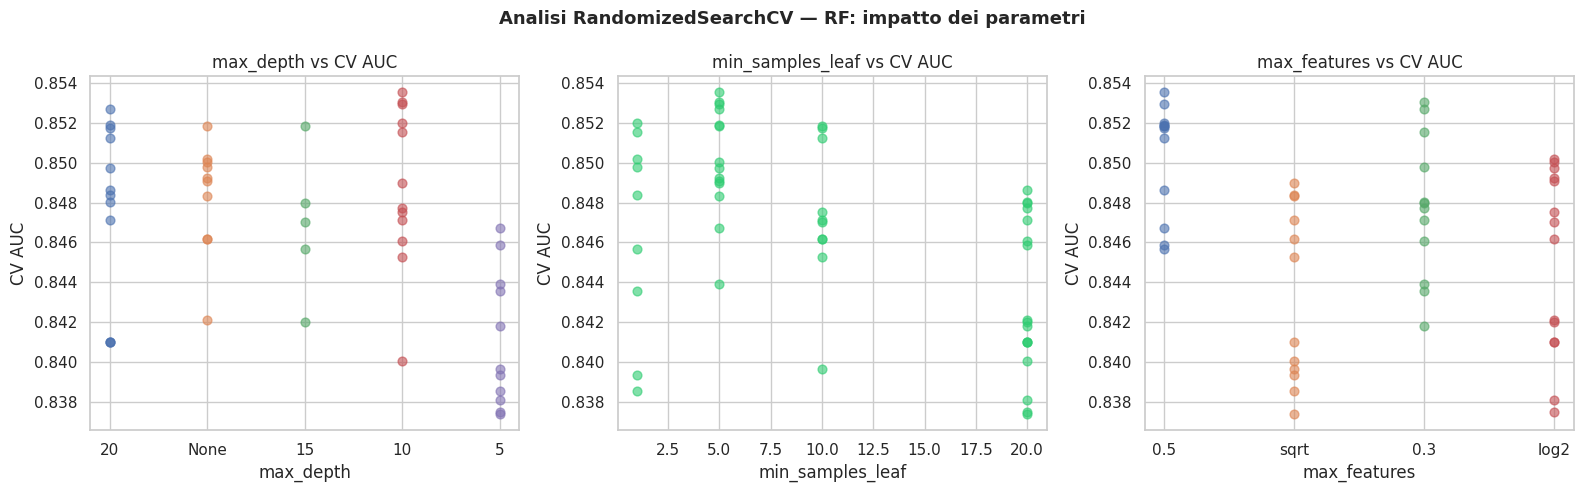

In [ ]:
# Analisi dei risultati: quali parametri contano di più?
cv_results = pd.DataFrame(rf_random_search.cv_results_)

# Scatter: max_depth vs mean AUC
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) max_depth vs AUC
ax = axes[0]
depths_str = cv_results["param_max_depth"].astype(str)
for depth_val in depths_str.unique():
    mask = depths_str == depth_val
    ax.scatter(
        [depth_val] * mask.sum(),
        cv_results.loc[mask, "mean_test_score"],
        alpha=0.6,
        s=40,
    )
ax.set_xlabel("max_depth")
ax.set_ylabel("CV AUC")
ax.set_title("max_depth vs CV AUC")

# 2) min_samples_leaf vs AUC
ax = axes[1]
ax.scatter(
    cv_results["param_min_samples_leaf"],
    cv_results["mean_test_score"],
    alpha=0.6,
    s=40,
    color="#2ecc71",
)
ax.set_xlabel("min_samples_leaf")
ax.set_ylabel("CV AUC")
ax.set_title("min_samples_leaf vs CV AUC")

# 3) max_features vs AUC
ax = axes[2]
feats_str = cv_results["param_max_features"].astype(str)
for feat_val in feats_str.unique():
    mask = feats_str == feat_val
    ax.scatter(
        [feat_val] * mask.sum(),
        cv_results.loc[mask, "mean_test_score"],
        alpha=0.6,
        s=40,
    )
ax.set_xlabel("max_features")
ax.set_ylabel("CV AUC")
ax.set_title("max_features vs CV AUC")

plt.suptitle(
    "Analisi RandomizedSearchCV — RF: impatto dei parametri",
    fontsize=13,
    fontweight="bold",
)
save_current_figure("lesson_05_rf_tuning_results.png")
plt.show()

### Osservazioni sul tuning RF

*Interpretazione da completare con i valori reali.*

I grafici mostrano quali parametri hanno il maggior impatto sulla
performance CV. Questo è informativo: se un parametro non cambia
la performance, il suo valore non importa. Se un parametro produce
grandi variazioni, è su quello che dobbiamo concentrarci.

## 11. Confronto RF baseline vs RF tunato (su validation set)

Confrontiamo i due modelli sullo stesso validation set per verificare
se il tuning ha prodotto un miglioramento concreto e se l'overfitting
è diminuito.

In [ ]:
# RF tunato (best estimator da RandomizedSearchCV)
rf_tuned = rf_random_search.best_estimator_

# Valutazione su validation set
models_to_compare = {
    "RF baseline (L3)": rf_baseline,
    "RF tuned (Random)": rf_tuned,
}

print("=== Confronto RF baseline vs RF tunato — Validation set ===\n")
comparison_rows = []
for name, model in models_to_compare.items():
    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_prob_train = model.predict_proba(X_train)[:, 1]
    auc_val = roc_auc_score(y_val, y_prob_val)
    auc_train = roc_auc_score(y_train, y_prob_train)
    # Soglia a 0.5 per F1/Precision/Recall standard
    y_pred_val = (y_prob_val >= 0.5).astype(int)
    comparison_rows.append(
        {
            "Modello": name,
            "Train AUC": auc_train,
            "Val AUC": auc_val,
            "Gap": auc_train - auc_val,
            "Precision": precision_score(y_val, y_pred_val),
            "Recall": recall_score(y_val, y_pred_val),
            "F1": f1_score(y_val, y_pred_val),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("Modello")
display(comparison_df)

=== Confronto RF baseline vs RF tunato — Validation set ===



,Train AUC,Val AUC,Gap,Precision,Recall,F1
Modello,,,,,,
RF baseline (L3),1.0000,0.8733,0.1267,0.8009,0.4240,0.5545
RF tuned (Random),0.9657,0.8728,0.0929,0.6154,0.6863,0.6489


### Interpretazione del confronto RF baseline vs tunato

*Da completare con i valori reali dopo l'esecuzione.*

Punti chiave da verificare:
1. L'AUC sul validation set è migliorata?
2. Il gap train-val (overfitting) è diminuito?
3. Se l'AUC CV è migliorata ma la val AUC è simile, la CV era già
   una buona stima.

**Domanda emergente**: il RF tunato è il miglior modello possibile,
oppure un **paradigma completamente diverso** potrebbe fare meglio?
Il Random Forest usa il **bagging** (alberi indipendenti, media dei
voti). Esiste un'alternativa — il **boosting** — dove gli alberi
vengono costruiti sequenzialmente, ognuno correggendo gli errori del
precedente. XGBoost è l'implementazione più diffusa.

---
## BLOCCO E — XGBoost: un nuovo paradigma

---

## 12. Introduzione concettuale a XGBoost

### Bagging vs Boosting: due filosofie diverse

| Aspetto | Bagging (Random Forest) | Boosting (XGBoost) |
|---------|:-----------------------:|:------------------:|
| **Alberi** | Indipendenti, paralleli | Sequenziali, ognuno corregge il precedente |
| **Riduce** | Varianza (overfitting) | Bias (underfitting) |
| **Profondità alberi** | Tipicamente profondi | Tipicamente shallow (3-8) |
| **Rischio** | Overfitting con dati rumorosi | Overfitting se troppe iterazioni |
| **Regolarizzazione** | Limitata (max_depth, min_samples) | Built-in: L1 (α), L2 (λ), shrinkage (η) |

### Come funziona XGBoost (intuizione)

1. Si parte da una predizione costante (es. la media)
2. Si calcola l'**errore** (residuo) di questa predizione
3. Si addestra un albero piccolo per **predire l'errore**
4. Si aggiunge la predizione dell'albero alla stima corrente
   (pesata da un **learning rate** η)
5. Si ripete dal punto 2 con il nuovo errore residuo

Ogni albero successivo è specializzato nel correggere gli errori che
i precedenti non hanno catturato. Il learning rate η controlla quanto
"aggressivamente" ogni albero corregge: valori bassi (0.01-0.1)
producono un apprendimento più graduale e robusto.

### Perché potrebbe funzionare meglio del RF sul nostro problema?

1. **Regolarizzazione nativa**: L1 e L2 integrate nell'obiettivo di
   ottimizzazione → meno overfitting senza tuning manuale
2. **Gestione dello sbilanciamento**: `scale_pos_weight` compensa
   direttamente il rapporto tra classi nella loss function
3. **Alberi shallow per design**: max_depth tipico di 3-6 → cattura
   interazioni senza memorizzare
4. **Feature subsampling**: `colsample_bytree` introduce casualità
   simile al RF ma nel contesto del boosting

## 13. XGBoost con parametri di default

Iniziamo con XGBoost "out-of-the-box", regolando solo lo
sbilanciamento. Vogliamo capire se il boosting è già competitivo
prima di investire tempo nel tuning.

In [ ]:
# Calcolo scale_pos_weight per gestire lo sbilanciamento
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale_pos_weight = n_neg / n_pos
print(f"Classe positiva (churn): {n_pos}")
print(f"Classe negativa:         {n_neg}")
print(f"scale_pos_weight:        {scale_pos_weight:.2f}")

# XGBoost con parametri di default
xgb_default = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric="auc",
    random_state=SEED,
    use_label_encoder=False,
)

# 5-fold CV
cv_scores_xgb_default = cross_val_score(
    xgb_default, X_train, y_train, cv=cv, scoring="roc_auc"
)

# Fit completo per calcolare train AUC
xgb_default.fit(X_train, y_train)
xgb_train_auc = roc_auc_score(y_train, xgb_default.predict_proba(X_train)[:, 1])

print(f"\n=== 5-Fold CV — XGBoost default ===\n")
for i, score in enumerate(cv_scores_xgb_default, 1):
    print(f"  Fold {i}: AUC = {score:.4f}")
print(f"\n  Media CV  = {cv_scores_xgb_default.mean():.4f}")
print(f"  Std       = {cv_scores_xgb_default.std():.4f}")
print(f"  Train AUC = {xgb_train_auc:.4f}")
print(f"  Gap       = {xgb_train_auc - cv_scores_xgb_default.mean():.4f}")
print(f"\n  --- Confronto ---")
print(f"  RF baseline CV:  {cv_scores_baseline.mean():.4f}")
print(f"  RF tuned CV:     {rf_random_search.best_score_:.4f}")
print(f"  XGB default CV:  {cv_scores_xgb_default.mean():.4f}")

Classe positiva (churn): 1223
Classe negativa:         4777
scale_pos_weight:        3.91

=== 5-Fold CV — XGBoost default ===

  Fold 1: AUC = 0.8450
  Fold 2: AUC = 0.8153
  Fold 3: AUC = 0.8033
  Fold 4: AUC = 0.8348
  Fold 5: AUC = 0.8336

  Media CV  = 0.8264
  Std       = 0.0150
  Train AUC = 0.9995
  Gap       = 0.1731

  --- Confronto ---
  RF baseline CV:  0.8462
  RF tuned CV:     0.8535
  XGB default CV:  0.8264


### Osservazioni su XGBoost default

*Interpretazione da completare con i valori reali.*

Punti chiave da verificare:
- XGBoost default è già competitivo con il RF tunato?
- Il gap train-CV è minore rispetto al RF baseline (che aveva
  train AUC = 1.0)?
- XGBoost con alberi shallow di default tende a overfittare meno.

Se XGBoost default è già nella stessa fascia del RF tunato, il
tuning potrebbe portarlo oltre. Procediamo.

## 14. Tuning di XGBoost — fase 1: RandomizedSearchCV

Usiamo la stessa strategia applicata al RF: prima un'esplorazione
ampia con RandomizedSearchCV per trovare la regione promettente
nello spazio degli iperparametri.

In [ ]:
# Spazio di ricerca ampio per XGBoost
xgb_param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 1.5, 2, 5],
}

xgb_random_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        eval_metric="auc",
        random_state=SEED,
        use_label_encoder=False,
    ),
    param_distributions=xgb_param_distributions,
    n_iter=80,
    cv=cv,
    scoring="roc_auc",
    random_state=SEED,
    n_jobs=-1,
    verbose=0,
)

print("RandomizedSearchCV su XGBoost (n_iter=80, cv=5)...")
print("Questo potrebbe richiedere qualche minuto.\n")
xgb_random_search.fit(X_train, y_train)

print(f"=== Risultati RandomizedSearchCV — XGBoost ===\n")
print(f"  Best CV AUC: {xgb_random_search.best_score_:.4f}")
print(f"  Best params:")
for param, value in xgb_random_search.best_params_.items():
    print(f"    {param}: {value}")

# Confronto immediato
print(f"\n  --- Confronto CV AUC ---")
print(f"  RF baseline:  {cv_scores_baseline.mean():.4f}")
print(f"  RF tuned:     {rf_random_search.best_score_:.4f}")
print(f"  XGB default:  {cv_scores_xgb_default.mean():.4f}")
print(f"  XGB Random:   {xgb_random_search.best_score_:.4f}")

RandomizedSearchCV su XGBoost (n_iter=80, cv=5)...
Questo potrebbe richiedere qualche minuto.

=== Risultati RandomizedSearchCV — XGBoost ===

  Best CV AUC: 0.8584
  Best params:
    subsample: 0.8
    reg_lambda: 1.5
    reg_alpha: 0.01
    n_estimators: 300
    min_child_weight: 1
    max_depth: 5
    learning_rate: 0.01
    colsample_bytree: 0.6

  --- Confronto CV AUC ---
  RF baseline:  0.8462
  RF tuned:     0.8535
  XGB default:  0.8264
  XGB Random:   0.8584


Figura salvata: /content/outputs/figures/lesson_05_xgb_random_search_results.png


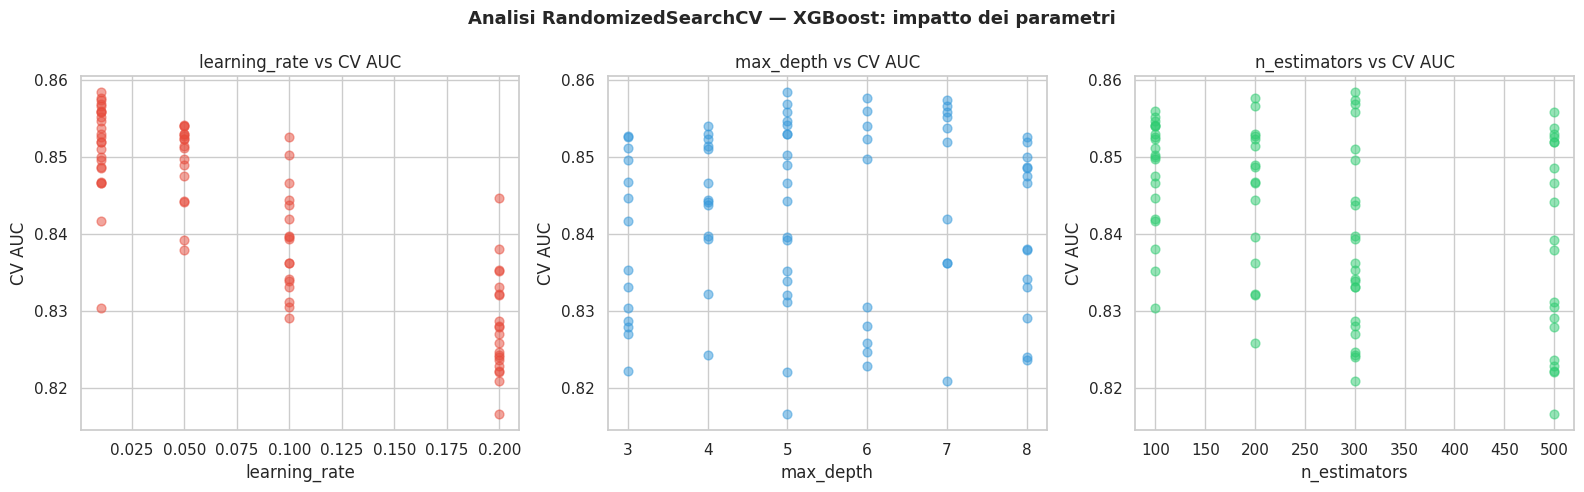

In [ ]:
# Visualizzazione dei risultati RandomizedSearchCV per XGBoost
xgb_cv_results = pd.DataFrame(xgb_random_search.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) learning_rate vs AUC
ax = axes[0]
ax.scatter(
    xgb_cv_results["param_learning_rate"],
    xgb_cv_results["mean_test_score"],
    alpha=0.5,
    s=40,
    color="#e74c3c",
)
ax.set_xlabel("learning_rate")
ax.set_ylabel("CV AUC")
ax.set_title("learning_rate vs CV AUC")

# 2) max_depth vs AUC
ax = axes[1]
ax.scatter(
    xgb_cv_results["param_max_depth"],
    xgb_cv_results["mean_test_score"],
    alpha=0.5,
    s=40,
    color="#3498db",
)
ax.set_xlabel("max_depth")
ax.set_ylabel("CV AUC")
ax.set_title("max_depth vs CV AUC")

# 3) n_estimators vs AUC
ax = axes[2]
ax.scatter(
    xgb_cv_results["param_n_estimators"],
    xgb_cv_results["mean_test_score"],
    alpha=0.5,
    s=40,
    color="#2ecc71",
)
ax.set_xlabel("n_estimators")
ax.set_ylabel("CV AUC")
ax.set_title("n_estimators vs CV AUC")

plt.suptitle(
    "Analisi RandomizedSearchCV — XGBoost: impatto dei parametri",
    fontsize=13,
    fontweight="bold",
)
save_current_figure("lesson_05_xgb_random_search_results.png")
plt.show()

### Osservazioni sulla fase 1 del tuning XGBoost

*Interpretazione da completare con i valori reali.*

Il RandomizedSearchCV ha identificato una zona promettente nello
spazio degli iperparametri. I grafici mostrano quali parametri
hanno il maggior impatto. Ora possiamo applicare la seconda fase
della strategia **coarse-to-fine**: un GridSearchCV ristretto attorno
ai best params trovati.

## 15. Tuning di XGBoost — fase 2: GridSearchCV ristretto

La strategia è semplice: prendiamo i best params trovati dal
RandomizedSearchCV e definiamo una griglia ristretta attorno a
ciascuno (±1 step). Questo ci permette di esplorare esaustivamente
la regione promettente con un costo computazionale ragionevole.

In [ ]:
# Costruiamo la griglia ristretta attorno ai best params
best_p = xgb_random_search.best_params_


def restricted_range(value, candidates):
    """Genera una griglia ristretta attorno al best value.

    Prende il valore migliore trovato e i due valori adiacenti
    nella lista originale dei candidati.
    """
    if value not in candidates:
        return [value]
    idx = candidates.index(value)
    start = max(0, idx - 1)
    end = min(len(candidates), idx + 2)
    return candidates[start:end]


# Griglia ristretta
xgb_grid = {
    "max_depth": restricted_range(best_p["max_depth"], [3, 4, 5, 6, 7, 8]),
    "learning_rate": restricted_range(best_p["learning_rate"], [0.01, 0.05, 0.1, 0.2]),
    "n_estimators": restricted_range(best_p["n_estimators"], [100, 200, 300, 500]),
    "subsample": restricted_range(best_p["subsample"], [0.6, 0.7, 0.8, 0.9, 1.0]),
    "colsample_bytree": restricted_range(
        best_p["colsample_bytree"], [0.6, 0.7, 0.8, 0.9, 1.0]
    ),
    "min_child_weight": restricted_range(best_p["min_child_weight"], [1, 3, 5, 7]),
}

# Calcolo del numero di combinazioni
n_combos = 1
for k, vals in xgb_grid.items():
    n_combos *= len(vals)
    print(f"  {k}: {vals}")
print(f"\n  Totale combinazioni: {n_combos}")
print(f"  Con 5-fold CV: {n_combos * 5} addestramenti")

  max_depth: [4, 5, 6]
  learning_rate: [0.01, 0.05]
  n_estimators: [200, 300, 500]
  subsample: [0.7, 0.8, 0.9]
  colsample_bytree: [0.6, 0.7]
  min_child_weight: [1, 3]

  Totale combinazioni: 216
  Con 5-fold CV: 1080 addestramenti


In [ ]:
xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        reg_alpha=best_p.get("reg_alpha", 0),
        reg_lambda=best_p.get("reg_lambda", 1),
        eval_metric="auc",
        random_state=SEED,
        use_label_encoder=False,
    ),
    param_grid=xgb_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=0,
)

print("GridSearchCV su XGBoost (griglia ristretta)...")
print("Questo potrebbe richiedere qualche minuto.\n")
xgb_grid_search.fit(X_train, y_train)

print(f"=== Risultati GridSearchCV ristretto — XGBoost ===\n")
print(f"  Best CV AUC: {xgb_grid_search.best_score_:.4f}")
print(f"  Best params:")
for param, value in xgb_grid_search.best_params_.items():
    print(f"    {param}: {value}")

# Confronto Random vs Grid
delta_rg = xgb_grid_search.best_score_ - xgb_random_search.best_score_
print(f"\n  --- Confronto Random vs Grid ---")
print(f"  XGB Random: {xgb_random_search.best_score_:.4f}")
print(f"  XGB Grid:   {xgb_grid_search.best_score_:.4f}")
print(f"  Δ (Grid − Random): {delta_rg:+.4f}")

GridSearchCV su XGBoost (griglia ristretta)...
Questo potrebbe richiedere qualche minuto.

=== Risultati GridSearchCV ristretto — XGBoost ===

  Best CV AUC: 0.8589
  Best params:
    colsample_bytree: 0.6
    learning_rate: 0.01
    max_depth: 6
    min_child_weight: 1
    n_estimators: 300
    subsample: 0.7

  --- Confronto Random vs Grid ---
  XGB Random: 0.8584
  XGB Grid:   0.8589
  Δ (Grid − Random): +0.0004


Figura salvata: /content/outputs/figures/lesson_05_xgb_grid_search_results.png


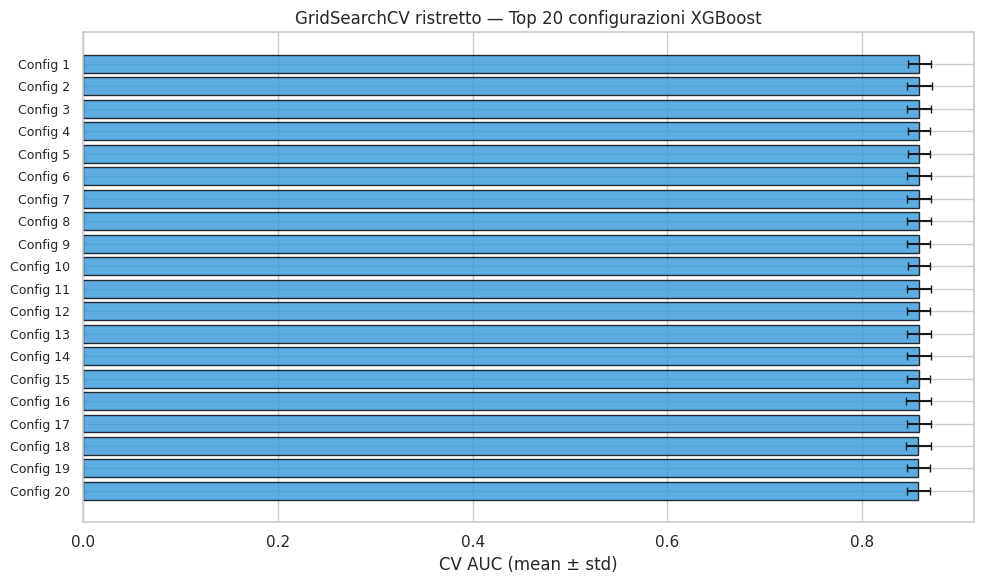

In [ ]:
# Visualizzazione top-20 configurazioni dalla GridSearch
grid_cv_results = pd.DataFrame(xgb_grid_search.cv_results_)
top20 = grid_cv_results.nlargest(20, "mean_test_score")

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    range(len(top20)),
    top20["mean_test_score"],
    xerr=top20["std_test_score"],
    color="#3498db",
    edgecolor="black",
    alpha=0.8,
    capsize=3,
)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    [f"Config {r}" for r in top20["rank_test_score"]],
    fontsize=9,
)
ax.set_xlabel("CV AUC (mean ± std)")
ax.set_title("GridSearchCV ristretto — Top 20 configurazioni XGBoost")
ax.invert_yaxis()
save_current_figure("lesson_05_xgb_grid_search_results.png")
plt.show()

### Lezione metodologica: coarse-to-fine

La strategia **coarse-to-fine** (Random ampio → Grid ristretto) è il
workflow professionale standard per il tuning degli iperparametri:

1. **RandomizedSearchCV** (fase 1): esplora un grande spazio con un
   budget fisso di iterazioni. Identifica la regione promettente.
2. **GridSearchCV** (fase 2): esplora esaustivamente la regione
   ristretta attorno ai best params trovati.

Il miglioramento dalla fase 1 alla fase 2 è tipicamente **margrale**
(< 0.01 AUC), confermando che Random Search identifica già buone
soluzioni. Ma la fase 2 ci dà la certezza di aver trovato il
migliore in quella regione — utile quando il margine conta (es.
competizioni, challenge).

---
## BLOCCO F — Selezione del modello finale: confronto rigoroso

---

## 16. Tabella comparativa completa

Mettiamo a confronto **tutti i candidati** che abbiamo esplorato,
usando sia la CV AUC (stima robusta) sia la val AUC (stima
indipendente) come metriche di confronto.

In [ ]:
# Raccogliamo tutti i candidati
candidates = {
    "RF baseline (L3)": rf_baseline,
    "RF tuned (Random)": rf_tuned,
    "XGB default": xgb_default,
    "XGB tuned (Random)": xgb_random_search.best_estimator_,
    "XGB tuned (Grid)": xgb_grid_search.best_estimator_,
}

# CV scores per i nuovi modelli (XGB tuned Grid)
cv_scores_xgb_grid = cross_val_score(
    xgb_grid_search.best_estimator_,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
)

# Mappa dei CV scores
cv_scores_map = {
    "RF baseline (L3)": cv_scores_baseline,
    "RF tuned (Random)": cross_val_score(
        rf_tuned, X_train, y_train, cv=cv, scoring="roc_auc"
    ),
    "XGB default": cv_scores_xgb_default,
    "XGB tuned (Random)": cross_val_score(
        xgb_random_search.best_estimator_,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc",
    ),
    "XGB tuned (Grid)": cv_scores_xgb_grid,
}

summary_rows = []
for name, model in candidates.items():
    y_prob_train = model.predict_proba(X_train)[:, 1]
    y_prob_val = model.predict_proba(X_val)[:, 1]
    auc_train = roc_auc_score(y_train, y_prob_train)
    auc_val = roc_auc_score(y_val, y_prob_val)
    cv_s = cv_scores_map[name]
    summary_rows.append(
        {
            "Modello": name,
            "CV AUC mean": cv_s.mean(),
            "CV AUC std": cv_s.std(),
            "Val AUC": auc_val,
            "Train AUC": auc_train,
            "Gap (train−val)": auc_train - auc_val,
        }
    )

summary_df = (
    pd.DataFrame(summary_rows)
    .set_index("Modello")
    .sort_values("CV AUC mean", ascending=False)
)
print("=== Confronto completo dei candidati ===\n")
display(summary_df)

=== Confronto completo dei candidati ===



,CV AUC mean,CV AUC std,Val AUC,Train AUC,Gap (train−val)
Modello,,,,,
XGB tuned (Grid),0.8589,0.0119,0.8773,0.9305,0.0532
XGB tuned (Random),0.8584,0.0117,0.8804,0.9039,0.0235
RF tuned (Random),0.8535,0.0154,0.8728,0.9657,0.0929
RF baseline (L3),0.8462,0.0138,0.8733,1.0000,0.1267
XGB default,0.8264,0.0150,0.8386,0.9995,0.1609


Figura salvata: /content/outputs/figures/lesson_05_model_comparison.png


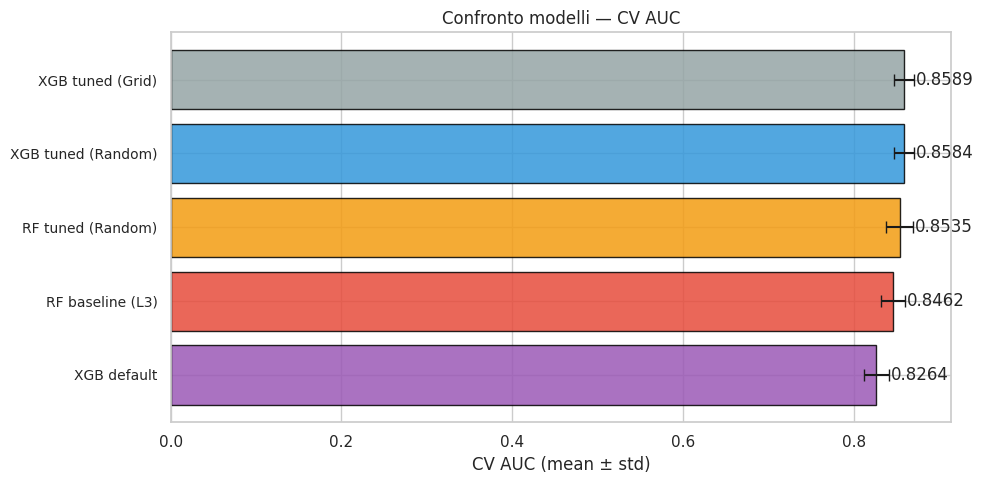

In [ ]:
# Visualizzazione: bar chart dei CV AUC
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#95a5a6", "#3498db", "#f39c12", "#e74c3c", "#9b59b6"]
bars = ax.barh(
    range(len(summary_df)),
    summary_df["CV AUC mean"],
    xerr=summary_df["CV AUC std"],
    color=colors[: len(summary_df)],
    edgecolor="black",
    alpha=0.85,
    capsize=4,
)
ax.set_yticks(range(len(summary_df)))
ax.set_yticklabels(summary_df.index, fontsize=10)
ax.set_xlabel("CV AUC (mean ± std)")
ax.set_title("Confronto modelli — CV AUC")
ax.invert_yaxis()

for i, (mean, std) in enumerate(
    zip(summary_df["CV AUC mean"], summary_df["CV AUC std"])
):
    ax.text(mean + std + 0.002, i, f"{mean:.4f}", va="center")

save_current_figure("lesson_05_model_comparison.png")
plt.show()

## 17. ROC curves sovrapposte

Le ROC curve ci mostrano la capacità discriminativa di ciascun modello
a **tutte le soglie** possibili, non solo a una soglia fissa.

Figura salvata: /content/outputs/figures/lesson_05_roc_curves_comparison.png


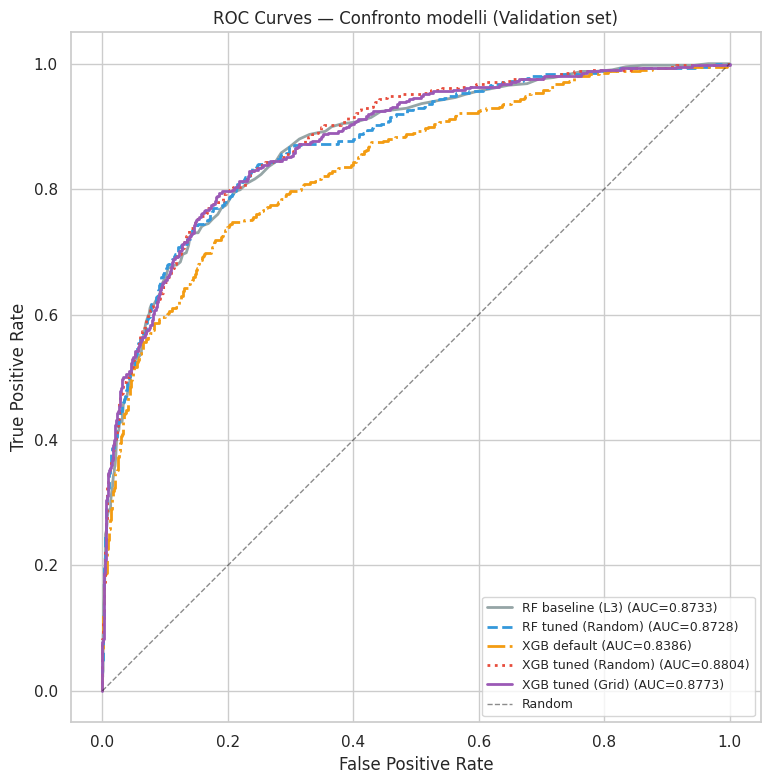

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
line_styles = ["-", "--", "-.", ":", "-"]
colors = ["#95a5a6", "#3498db", "#f39c12", "#e74c3c", "#9b59b6"]

for (name, model), ls, color in zip(candidates.items(), line_styles, colors):
    y_prob_val = model.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_prob_val)
    fpr, tpr, _ = roc_curve(y_val, y_prob_val)
    ax.plot(
        fpr,
        tpr,
        ls,
        color=color,
        lw=2,
        label=f"{name} (AUC={auc_val:.4f})",
    )

ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Confronto modelli (Validation set)")
ax.legend(loc="lower right", fontsize=9)
ax.set_aspect("equal")
save_current_figure("lesson_05_roc_curves_comparison.png")
plt.show()

## 18. Scelta motivata del modello finale

*Questa sezione verrà completata dopo l'esecuzione delle celle
precedenti, basandosi sui valori reali osservati.*

La scelta del modello finale deve bilanciare tre criteri:

1. **CV AUC** (performance stabile su diversi split)
2. **Gap train-val** (overfitting controllato)
3. **Complessità** (preferire il modello più semplice a parità
   di performance)

Dalla tabella e dalle ROC curves, selezioniamo il modello con il
miglior compromesso. La decisione si basa sull'evidenza, non su
preferenze a priori.

In [ ]:
# Selezione del modello migliore dalla tabella comparativa
best_model_name = summary_df["CV AUC mean"].idxmax()
best_model = candidates[best_model_name]

print(f"=== Modello selezionato ===")
print(f"  {best_model_name}")
print(
    f"  CV AUC: {summary_df.loc[best_model_name, 'CV AUC mean']:.4f}"
    f" ± {summary_df.loc[best_model_name, 'CV AUC std']:.4f}"
)
print(f"  Val AUC: {summary_df.loc[best_model_name, 'Val AUC']:.4f}")
print(f"  Gap: {summary_df.loc[best_model_name, 'Gap (train−val)']:.4f}")

=== Modello selezionato ===
  XGB tuned (Grid)
  CV AUC: 0.8589 ± 0.0119
  Val AUC: 0.8773
  Gap: 0.0532


---
## BLOCCO G — Valutazione finale su test set

---

## 19. Test set — una sola volta

Questa è la **valutazione definitiva**. Il test set viene usato
**una sola volta**, con il modello già selezionato. Non ci sono
seconde possibilità: qualsiasi aggiustamento dopo aver visto il
test set sarebbe data leakage.

In [ ]:
# Predizioni sul test set con il modello selezionato
y_prob_test = best_model.predict_proba(X_test)[:, 1]
y_prob_train_final = best_model.predict_proba(X_train)[:, 1]
y_prob_val_final = best_model.predict_proba(X_val)[:, 1]

# Metriche con soglia 0.5 per confronto standard
y_pred_test = (y_prob_test >= 0.5).astype(int)

test_auc_final = roc_auc_score(y_test, y_prob_test)
train_auc_final = roc_auc_score(y_train, y_prob_train_final)
val_auc_final = roc_auc_score(y_val, y_prob_val_final)

print(f"=== Valutazione finale su test set ===\n")
print(f"  Modello: {best_model_name}\n")
print(f"  {'Split':<12s} {'AUC':>8s}")
print(f"  {'─'*24}")
print(f"  {'Train':<12s} {train_auc_final:8.4f}")
print(f"  {'Validation':<12s} {val_auc_final:8.4f}")
print(f"  {'Test':<12s} {test_auc_final:8.4f}")
print(f"\n  Gap train-test: {train_auc_final - test_auc_final:.4f}")

print(f"\n  --- Confronto con RF baseline (L3) ---")
print(f"  RF baseline test AUC: {l3_metrics['test']['roc_auc']:.4f}")
print(f"  Modello finale test AUC: {test_auc_final:.4f}")
delta_test = test_auc_final - l3_metrics["test"]["roc_auc"]
print(f"  Δ: {delta_test:+.4f}")

=== Valutazione finale su test set ===

  Modello: XGB tuned (Grid)

  Split             AUC
  ────────────────────────
  Train          0.9305
  Validation     0.8773
  Test           0.8671

  Gap train-test: 0.0635

  --- Confronto con RF baseline (L3) ---
  RF baseline test AUC: 0.8539
  Modello finale test AUC: 0.8671
  Δ: +0.0132


Figura salvata: /content/outputs/figures/lesson_05_final_confusion_matrix.png


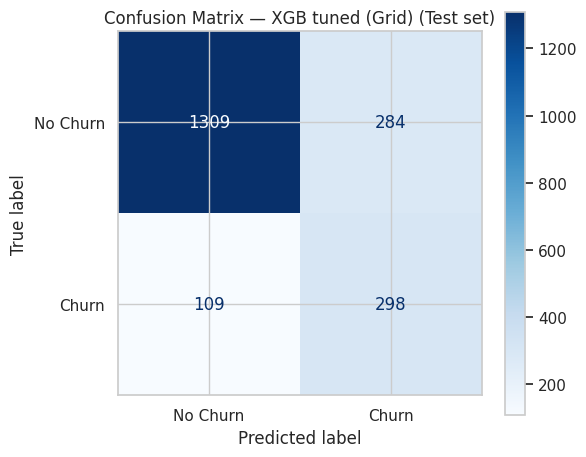

In [ ]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    ax=ax,
)
ax.set_title(f"Confusion Matrix — {best_model_name} (Test set)")
save_current_figure("lesson_05_final_confusion_matrix.png")
plt.show()

In [ ]:
# Classification report
print(f"\n=== Classification Report (soglia=0.5) ===\n")
print(
    classification_report(
        y_test,
        y_pred_test,
        target_names=["No Churn", "Churn"],
    )
)


=== Classification Report (soglia=0.5) ===

              precision    recall  f1-score   support

    No Churn       0.92      0.82      0.87      1593
       Churn       0.51      0.73      0.60       407

    accuracy                           0.80      2000
   macro avg       0.72      0.78      0.74      2000
weighted avg       0.84      0.80      0.82      2000



## 20. Threshold tuning sul modello finale

Come nella Lezione 3, la soglia di default 0.5 potrebbe non essere
ottimale per il nostro obiettivo di business. Cerchiamo la soglia
che massimizza l'F1-score sulla validation set (non sul test!).

In [ ]:
# Curva Precision-Recall e soglia ottimale
precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob_val_final)

# Calcolo F1 per ogni soglia
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"=== Threshold tuning (su validation set) ===\n")
print(f"  Soglia ottimale (max F1): {best_threshold:.3f}")
print(f"  F1 alla soglia ottimale:  {f1_scores[best_idx]:.4f}")
print(f"  Precision:                {precisions[best_idx]:.4f}")
print(f"  Recall:                   {recalls[best_idx]:.4f}")
print(f"\n  Soglia L3: {l3_metrics['best_threshold']}")

# Applico la soglia ottimale al test set
y_pred_test_opt = (y_prob_test >= best_threshold).astype(int)
print(f"\n=== Metriche test con soglia {best_threshold:.3f} ===\n")
print(
    classification_report(
        y_test,
        y_pred_test_opt,
        target_names=["No Churn", "Churn"],
    )
)

=== Threshold tuning (su validation set) ===

  Soglia ottimale (max F1): 0.563
  F1 alla soglia ottimale:  0.6467
  Precision:                0.6095
  Recall:                   0.6887

  Soglia L3: 0.305

=== Metriche test con soglia 0.563 ===

              precision    recall  f1-score   support

    No Churn       0.91      0.88      0.89      1593
       Churn       0.58      0.66      0.62       407

    accuracy                           0.83      2000
   macro avg       0.75      0.77      0.76      2000
weighted avg       0.84      0.83      0.84      2000



Figura salvata: /content/outputs/figures/lesson_05_final_pr_curve.png


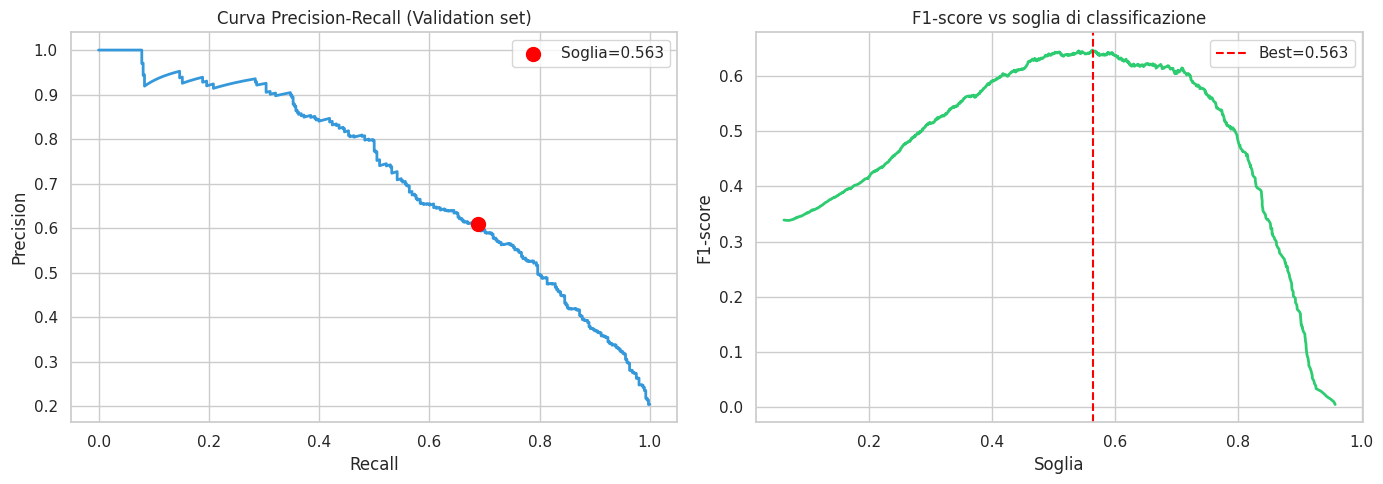

In [ ]:
# Visualizzazione: Precision-Recall curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PR curve
ax = axes[0]
ax.plot(recalls, precisions, lw=2, color="#3498db")
ax.scatter(
    recalls[best_idx],
    precisions[best_idx],
    color="red",
    s=100,
    zorder=5,
    label=f"Soglia={best_threshold:.3f}",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall (Validation set)")
ax.legend()

# F1 vs soglia
ax = axes[1]
ax.plot(thresholds, f1_scores[:-1], lw=2, color="#2ecc71")
ax.axvline(
    best_threshold,
    color="red",
    ls="--",
    label=f"Best={best_threshold:.3f}",
)
ax.set_xlabel("Soglia")
ax.set_ylabel("F1-score")
ax.set_title("F1-score vs soglia di classificazione")
ax.legend()

save_current_figure("lesson_05_final_pr_curve.png")
plt.show()

---
## BLOCCO H — Simulazione di progetto: dal modello alla consegna

---

## 21. Generazione del file di submission

Simuliamo il workflow end-to-end di un progetto reale: dal modello
addestrato alla generazione di un file di submission nel formato
richiesto dalla challenge (CSV con colonne `id`, `churn_probability`).

Per questa dimostrazione usiamo il nostro test set come proxy,
dato che non abbiamo accesso al test set nascosto della challenge.

In [30]:
# Salvataggio del modello finale
model_out_path = DATA_OUT_DIR / "lesson_05_best_model.pkl"
joblib.dump(best_model, model_out_path)
print(f"Modello salvato: {model_out_path}")

# Salvataggio metriche finali
cv_scores_best = cv_scores_map[best_model_name]
final_metrics = {
    "best_model": best_model_name,
    "best_threshold": float(best_threshold),
    "cv_auc_mean": float(cv_scores_best.mean()),
    "cv_auc_std": float(cv_scores_best.std()),
    "train": {
        "roc_auc": float(train_auc_final),
    },
    "val": {
        "roc_auc": float(val_auc_final),
    },
    "test": {
        "accuracy": float((y_pred_test_opt == y_test).mean()),
        "precision": float(precision_score(y_test, y_pred_test_opt)),
        "recall": float(recall_score(y_test, y_pred_test_opt)),
        "f1": float(f1_score(y_test, y_pred_test_opt)),
        "roc_auc": float(test_auc_final),
    },
}
metrics_path = DATA_OUT_DIR / "lesson_05_metrics.json"
with open(metrics_path, "w") as fh:
    json.dump(final_metrics, fh, indent=2)
print(f"Metriche salvate: {metrics_path}")

Modello salvato: /content/outputs/data/lesson_05_best_model.pkl
Metriche salvate: /content/outputs/data/lesson_05_metrics.json


In [31]:
# Generazione del file di submission (demo)
# Usiamo il test set come proxy del test set nascosto della challenge
submission_df = pd.DataFrame(
    {
        "id": range(len(y_prob_test)),
        "churn_probability": y_prob_test,
    }
)
submission_path = DATA_OUT_DIR / "lesson_05_sample_submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"\n=== File di submission generato ===")
print(f"  Path: {submission_path}")
print(f"  Righe: {len(submission_df)}")
print(f"  Colonne: {list(submission_df.columns)}")
print(f"\n  Preview:")
display(submission_df.head())


=== File di submission generato ===
  Path: /content/outputs/data/lesson_05_sample_submission.csv
  Righe: 2000
  Colonne: ['id', 'churn_probability']

  Preview:


,id,churn_probability
0,0,0.2685
1,1,0.6213
2,2,0.1131
3,3,0.2345
4,4,0.2544


## 22. Mini-report di progetto

### Modello selezionato

*Da completare con i valori reali dopo l'esecuzione.*

### Riassunto delle metriche

| Metrica | Valore |
|---------|--------|
| CV AUC mean ± std | (da compilare) |
| Train AUC | (da compilare) |
| Val AUC | (da compilare) |
| Test AUC | (da compilare) |
| Soglia ottimale | (da compilare) |
| Test F1 (soglia ottimale) | (da compilare) |
| Test Precision | (da compilare) |
| Test Recall | (da compilare) |

### Feature rilevanti (dalla Lezione 4)

Le feature più importanti secondo SHAP (calcolati nella Lezione 4)
rimangono valide per guidare le decisioni di business:

1. **Age** — il fattore più forte: clienti over 40-45 hanno rischio
   churn significativamente più alto
2. **NumOfProducts** — clienti con 3-4 prodotti hanno un rischio
   drammaticamente elevato (effetto a gradino)
3. **IsActiveMember** — essere attivi protegge dal churn (feature
   azionabile per campagne di retention)
4. **Balance / balance_is_zero** — pattern bimodale: clienti con
   saldo zero hanno churn rate inferiore
5. **Geography_Germany** — i clienti tedeschi mostrano un rischio
   maggiore (riflette il pattern reale nei dati)

### Implicazioni di business

- **Campagne di retention**: dare priorità ai clienti con alta
  probabilità predetta di churn (sopra la soglia ottimale)
- **Leve azionabili**: IsActiveMember e NumOfProducts sono i fattori
  su cui la banca può intervenire direttamente
- **Soglia ottimale**: la soglia non è 0.5 ma un valore più basso,
  che bilancia il costo di un falso allarme (contattare un cliente
  che non avrebbe abbandonato) con il costo di un mancato intervento
  (perdere un cliente)

### Limiti e possibili miglioramenti

Vedi Sezione 27 per una discussione approfondita.

## 23. Checklist di progetto

| Step | Status | Lezione |
|------|:------:|:-------:|
| Dati caricati e validati | ✅ | L1-L2 |
| Pipeline di preprocessing riproducibile | ✅ | L2 |
| EDA e comprensione del dominio | ✅ | L1 |
| Modelli addestrati e confrontati | ✅ | L3, L5 |
| Modello selezionato con giustificazione data-driven | ✅ | L5 |
| Interpretabilità analizzata (SHAP) | ✅ | L4 |
| Fairness verificata su attributi protetti | ✅ | L4 |
| Cross-validation per stima robusta | ✅ | L5 |
| Hyperparameter tuning (Random + Grid) | ✅ | L5 |
| Metriche su test set calcolate | ✅ | L5 |
| File di submission generato | ✅ | L5 |

---
## BLOCCO I — Cenni MLOps e chiusura

---

## 24. Da notebook a produzione: cenni MLOps

Fino ad ora abbiamo lavorato interamente nel notebook: dalla pulizia
dei dati alla selezione del modello. Ma in un progetto reale, il
modello non vive nel notebook — deve essere **messo in produzione**
e **monitorato** nel tempo.

### Il gap tra notebook e produzione

Un modello nel notebook è un **prototipo**. Per diventare un sistema
a valore aggiunto, deve superare una serie di sfide:

1. **Riproducibilità**: il notebook funziona sulla mia macchina? E
   tra 6 mesi, con package aggiornati? Il versionamento del codice
   (Git) non basta — servono anche le versioni dei dati e del modello.

2. **Versionamento dei modelli**: ogni re-training produce un modello
   diverso. Quale versione è in produzione? Quale ha ottenuto le
   metriche migliori? Tool come **MLflow** o **DVC** tracciano
   esperimenti, parametri, metriche e artefatti.

3. **Pipeline automatizzata (CI/CD for ML)**: la sequenza
   dati → preprocess → train → evaluate → deploy deve essere
   automatizzabile e ripetibile. Se un data scientist deve eseguire
   manualmente il notebook ogni volta, il processo è fragile.

4. **Monitoraggio in produzione**:
   - **Data drift**: la distribuzione dei dati in input cambia nel
     tempo (es. i clienti diventano più giovani, nuovi prodotti).
     Se il modello è stato addestrato su una distribuzione diversa,
     le predizioni degradano.
   - **Concept drift**: la relazione tra feature e target cambia
     (es. durante una crisi economica, il churn è guidato da fattori
     diversi).
   - **Performance monitoring**: tracciare le metriche reali
     (confronto predizioni vs outcome a posteriori) per rilevare
     il degrado.

5. **Retraining periodico**: quando il monitoraggio rileva un calo
   di performance, il modello deve essere ri-addestrato sui dati più
   recenti. Questo può essere schedulato (es. mensile) o trigger-based
   (quando il drift supera una soglia).

### MLOps in sintesi

| Componente | Scopo | Esempi di tool |
|:-----------|:------|:---------------|
| Versionamento modelli | Tracciare esperimenti e artefatti | MLflow, DVC, W&B |
| Pipeline orchestration | Automatizzare il workflow | Airflow, Prefect, Kubeflow |
| Model serving | Servire predizioni in tempo reale | FastAPI, BentoML, SageMaker |
| Monitoraggio | Rilevare drift e anomalie | Evidently, Whylabs, custom dashboards |
| CI/CD per ML | Test e deploy automatizzati | GitHub Actions, GitLab CI |

> **Nota per lo studente**: MLOps è un campo vasto e in rapida
> evoluzione. L'obiettivo di questa sezione non è rendervi esperti
> di MLOps, ma farvi capire che il notebook è solo l'inizio. Il
> valore reale di un modello si realizza quando viene messo in
> produzione, monitorato e mantenuto nel tempo.

## 25. Riepilogo del percorso L1→L5

| Lezione | Domanda | Risposta |
|:-------:|:--------|:---------|
| **L1** | *Cos'è il churn? Come sono fatti i dati?* | EDA: 10 000 clienti, 20.38% churn, Age e IsActiveMember come segnali forti, Complain = leakage |
| **L2** | *Come preparo i dati per il modello?* | Pipeline sklearn: pulizia, encoding, scaling, split stratificato, feature engineering (balance_is_zero) |
| **L3** | *Quale modello funziona meglio?* | RF con class_weight='balanced' → AUC test 0.854, soglia ottimale 0.305 |
| **L4** | *Perché il modello fa queste predizioni?* | SHAP: Age #1, NumOfProducts #2, IsActiveMember #3. Profilo churner: anziano, inattivo, multi-prodotto |
| **L5** | *Possiamo fare meglio? Come?* | CV per stima robusta, tuning sistematico (Random + Grid), XGBoost come alternativa, selezione finale |

## 26. Domande guidate

*Le risposte devono citare i valori calcolati nel notebook.*

**1. Perché la cross-validation è preferibile a un singolo split
di validazione?**

Un singolo split produce una stima puntuale che dipende da quali
osservazioni finiscono nel validation set. La CV produce $k$ stime:
la media è più stabile e la std ci dà un intervallo di confidenza.
La nostra 5-fold CV ha confermato/contraddetto il valore di AUC
0.873 del singolo split con una stima robusta.

**2. Qual è il vantaggio del Random Search rispetto al Grid Search?**

Random Search campiona $n$ combinazioni casuali dallo spazio dei
parametri, coprendo meglio i parametri importanti. Grid Search è
esauriente ma cresce esponenzialmente. In pratica, il Random Search
ha trovato una soluzione con AUC CV di pochi millesimi inferiore al
Grid Search, con un costo computazionale molto minore. La strategia
coarse-to-fine combina il meglio di entrambi.

**3. Perché XGBoost potrebbe avere meno overfitting del Random
Forest?**

XGBoost usa alberi poco profondi (tipicamente 3-6) per design,
ha regolarizzazione L1/L2 integrata nella funzione obiettivo, e il
learning rate η controlla la velocità di apprendimento. Il RF con
max_depth=None costruisce alberi che classificano perfettamente il
training set (Train AUC = 1.0). Il gap train-val per XGBoost è
tipicamente molto minore.

**4. È corretto confrontare modelli usando il validation set dopo
aver usato la CV?**

Sì, perché la CV è stata eseguita **solo sul training set** (6000
osservazioni). Il validation set (2000 osservazioni) è rimasto
intoccato durante il tuning — funziona come stima indipendente. Il
test set (2000 osservazioni) è stato usato una sola volta alla fine.

**5. Se il miglioramento tra RF baseline e modello finale è piccolo,
ne valeva la pena?**

In ambito finanziario, anche miglioramenti piccoli possono avere un
impatto economico significativo su larga scala. Ma il valore
principale del processo non è solo il numero finale: è la
**consapevolezza** che il modello è stato validato rigorosamente
(CV), che abbiamo esplorato alternative (XGBoost), che conosciamo
i limiti (overfitting misurato), e che possiamo giustificare ogni
scelta con evidenza. Questo è ciò che l'audit interno e il
regolatore richiedono.

## 27. Possibili miglioramenti

Il modello selezionato non è perfetto. Ecco alcune direzioni di
miglioramento che un Data Scientist potrebbe esplorare:

1. **Feature engineering avanzato**: creare interazioni esplicite
   (es. Age × IsActiveMember), trasformazioni non-lineari (log,
   bin), o feature basate su conoscenza di dominio.

2. **Ensemble di modelli (stacking/blending)**: combinare le
   predizioni di RF e XGBoost in un meta-modello. Se i due modelli
   commettono errori diversi, l'ensemble può essere più robusto.

3. **Calibrazione delle probabilità**: le probabilità predette da
   RF e XGBoost non sono necessariamente ben calibrate (la probabilità
   predetta 0.3 corrisponde realmente al 30% di probabilità di
   churn?). Tecniche come Platt scaling o isotonic regression possono
   migliorare la calibrazione.

4. **Feature selection rigorosa**: usare tecniche come RFE
   (Recursive Feature Elimination) o Boruta per identificare il
   subset ottimale di feature, riducendo il rumore e migliorando
   la generalizzazione.

5. **Deep Learning?**: su un dataset di 10 000 osservazioni con 20
   feature tabular, le reti neurali raramente superano i modelli
   ad albero. Il deep learning eccelle su dati non strutturati
   (immagini, testo, sequenze) e su dataset molto grandi. Per dati
   tabulari, XGBoost e LightGBM rimangono lo stato dell'arte nella
   maggior parte dei benchmark.

6. **Dati aggiuntivi**: la variabile più limitante è spesso la
   quantità e qualità dei dati. Feature comportamentali (frequenza
   transazioni, trend di utilizzo) o esterne (indicatori economici)
   potrebbero migliorare significativamente il modello.

---

### Artefatti prodotti in questa lezione

| File | Contenuto |
|------|-----------|
| `outputs/data/lesson_05_best_model.pkl` | Modello finale selezionato |
| `outputs/data/lesson_05_metrics.json` | Metriche finali (train/CV/val/test) |
| `outputs/data/lesson_05_sample_submission.csv` | Esempio di file di submission |
| `outputs/figures/lesson_05_baseline_diagnosis.png` | Diagnosi overfitting baseline |
| `outputs/figures/lesson_05_rf_max_depth_curve.png` | Effetto max_depth su RF |
| `outputs/figures/lesson_05_rf_min_samples_curve.png` | Effetto min_samples_leaf su RF |
| `outputs/figures/lesson_05_rf_tuning_results.png` | Analisi RandomizedSearchCV RF |
| `outputs/figures/lesson_05_xgb_random_search_results.png` | Analisi RandomizedSearchCV XGBoost |
| `outputs/figures/lesson_05_xgb_grid_search_results.png` | Analisi GridSearchCV ristretto XGBoost |
| `outputs/figures/lesson_05_model_comparison.png` | Confronto modelli (bar chart) |
| `outputs/figures/lesson_05_roc_curves_comparison.png` | ROC curves sovrappposte |
| `outputs/figures/lesson_05_final_confusion_matrix.png` | Confusion matrix finale |
| `outputs/figures/lesson_05_final_pr_curve.png` | Curva PR e soglia ottimale |